In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

🌟 **Exercise 1** : Understanding the problem and Data Collection


- Load the diabetes dataset and explore it.

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


- How many positive and negative cases is there ?

In [5]:
class_count = df['diabetes'].value_counts()
class_names = {0:'No diabetes', 1:'Diabetes'}
print(class_count.rename(index = class_names))

diabetes
No diabetes    91500
Diabetes        8500
Name: count, dtype: int64


- Split the data into training and testing sets


In [6]:
from sklearn.model_selection import train_test_split

target = 'diabetes'
X = df.drop(columns=['diabetes'])
y = df[target]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, test_size=0.30, random_state=1)


In [7]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(70000, 13) (30000, 13) (70000,) (30000,)


🌟 **Exercise 2** : Model Picking and Standardization

- Which classification model can we use in this problem and why ?



Since this is a **binary classification problem** (predicting whether a person has diabetes or not), we can use:
  --> **Logistic Regression**: A simple and effective model for binary classification. It predicts the probability of occurrence of an event by fitting data to a logistic curve.



- Do we need to standardize the data ? If yes, use .StandardScaler()


Since we are using **Logistic Regression**, we need to standardize the data, because it relies on gradient-based optimization and is sensitive to features scales.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🌟 **Exercise 3** : Model Training

In [9]:
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
model = LogisticRegression()

# Fit the model
model.fit(X_train_scaled, y_train)

# Make predictions
y_prob = model.predict_proba(X_test)[:, 1] # Probability of class 1


# Plot Results (Only possible for one feature)
if X.shape[1] == 1:  # Ensure we have only one feature for visualization
    X_range = np.linspace(X_test.min(), X_test.max(), 300).reshape(-1, 1)
    y_prob_curve = model.predict_proba(X_range)[:, 1]

    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label="Actual Data")
    plt.plot(X_range, y_prob_curve, color='red', linewidth=2, label="Logistic Regression Curve")
    plt.xlabel('Independent Variable (X)')
    plt.ylabel('Probability of Class 1 (y)')
    plt.title('Logistic Regression')
    plt.legend()
    plt.show()
else:
    print("Skipping plot: Logistic regression curve visualization is only possible with one feature.")


Skipping plot: Logistic regression curve visualization is only possible with one feature.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


🌟 **Exercise 4** : Evaluation Metrics

- Plot the accuracy score and comment the results.

Accuracy: 0.96


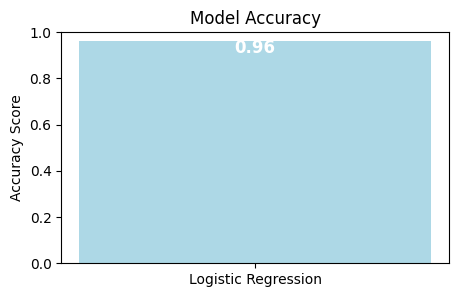

In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Plot accuracy
plt.figure(figsize=(5,3))
plt.bar(["Logistic Regression"], [accuracy], color='lightblue')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy")
plt.text(0, accuracy - 0.05, f"{accuracy:.2f}", ha='center', fontsize=12, color='white', weight='bold')  # Add label
plt.show()

The accuracy score is 96%, which is very high. This indicates that the logistic regression model is performing **very well** in predicting whether a person has diabetes.

- Plot the confusion matrix and comment the results.

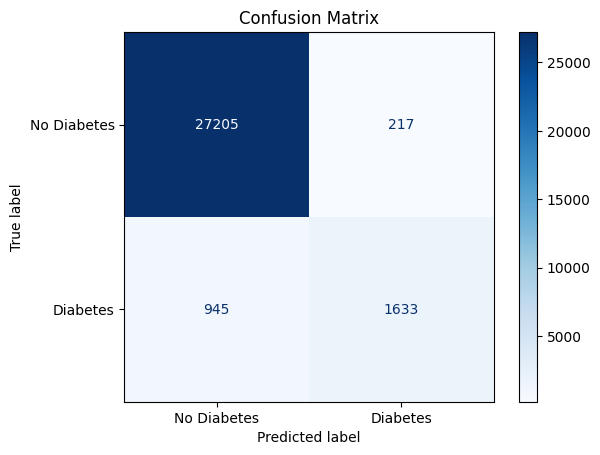

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


1. **High True Negative** (TN = 27205):
 - The model correctly identified a large number of people as "No Diabetes".
 - This suggests **good specificity**(ability to detect non-diabetic cases)

2. **High True Positives** (TP = 1633)
 - The model correctly identified many diabetic individuals.
 - This suggests good sensitivity (recall) but not perfect.

3. **False Positives** (FP = 217) are very low
 - Only 217 non-diabetic individuals were incorrectly classified as diabetic.
 - This means the model has high precision (low false alarms).

4. **False Negatives** (FN = 945) are significant
  - 945 actual diabetic cases were misclassified as "No Diabetes."
  - This is concerning because missing a diabetes diagnosis can be critical.
  - The recall for detecting diabetes may need improvement.

- Plot the Recall, precision, F1-score and comment the results.

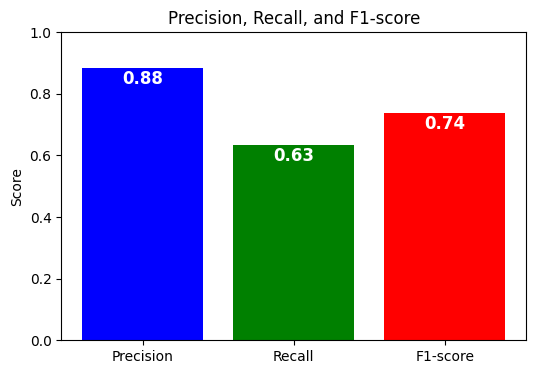

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Plot the scores
metrics = ['Precision', 'Recall', 'F1-score']
values = [precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.ylim(0, 1)  # Ensure values are between 0 and 1
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score")
for i, v in enumerate(values):
    plt.text(i, v - 0.05, f"{v:.2f}", ha='center', fontsize=12, color='white', weight='bold')
plt.show()


- **Precision** → Measures false alarms (false positives).
- **Recall** → Measures how many real cases the model detects (sensitivity).
- **F1-score** → A balance between both.

- **High Precison** (88%):
 - The model is very **confident** when it predicts "Diabetes".
 - Only 12% of the predicted "Diabetes" cases are false positives.
 - This means very few non-diabetic people are mistakenly classified as diabetic.

- **Low Recall** (63%) :
  - The model is missing 37% of real diabetes cases (false negatives).
  - This is a concern because many diabetic patients are not detected.
  - In medical applications, we prefer a higher recall to avoid missing real cases.

- **Moderate F1-score** (74%) :
  - F1-score is a balance between precision and recall.
  - Since recall is significantly lower than precision, the model might be too cautious in predicting diabetes.

🌟 **Exercise 5** : Visualizing the performance of our model

- Visualize the decision boundary with accuracy information.

Since logistic regression is a linear classifier, we can visualize the decision boundary if the dataset has only **two features** (eg. *blood_glucose_level* & *HbA1c_level*  (Highly correlated with diabetes)). This allows us to see how the model separates diabetic vs. non-diabetic individuals.


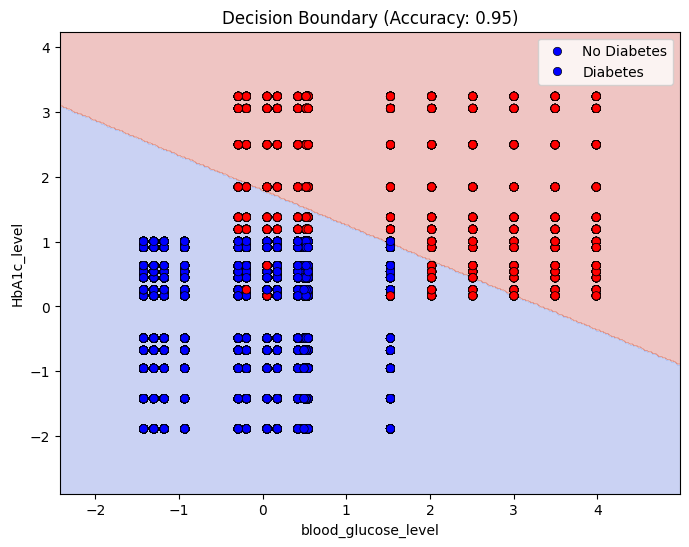

In [13]:
feature1 = "blood_glucose_level" # Direct measurement of blood sugar level
feature2 = "HbA1c_level" # Reflect average glucose levels over several months

X_vis = X_train[[feature1, feature2]]
X_vis_test = X_test[[feature1, feature2]]

scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)
X_vis_test_scaled = scaler.transform(X_vis_test)

# Train Logistic Regression on selected features
model_vis = LogisticRegression()
model_vis.fit(X_vis_scaled, y_train)

# Compute accuracy
y_pred_vis = model_vis.predict(X_vis_test_scaled)
accuracy = accuracy_score(y_test, y_pred_vis)

# Create a mesh grid for decision boundary
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict class for each point in the grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X_vis_scaled[:, 0], y=X_vis_scaled[:, 1], hue=y_train, edgecolor='black', palette={0: "blue", 1: "red"})

# Add accuracy info
plt.title(f"Decision Boundary (Accuracy: {accuracy:.2f})")
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend(["No Diabetes", "Diabetes"])
plt.show()

🌟 **Exercise 6** : ROC Curve

- Plot the ROC Curve using this code template available on this link


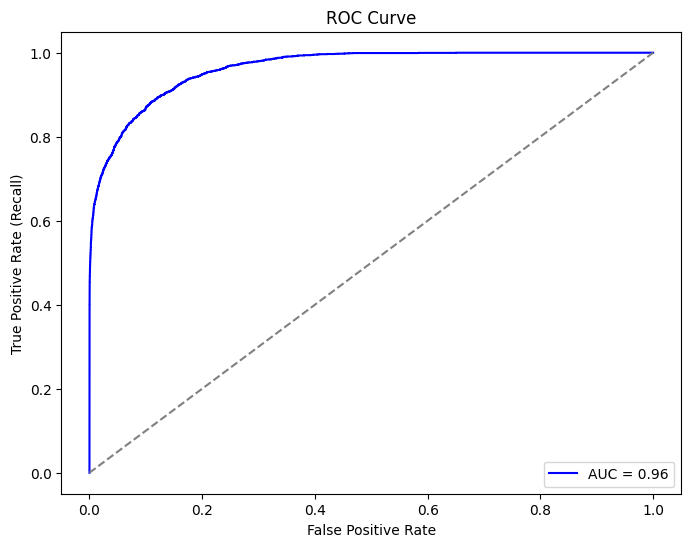

In [14]:
from sklearn import metrics

# Compute probability predictions
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

# Compute AUC (Area Under the Curve)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")  # Reference line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

AUC is close to 1 (0.96) → **`Excellent model.`**